# Lecture 6 — Class Exercise
## Part-to-Whole: Hierarchical Visualization

> **Push to:** `week06/lecture06_exercise.ipynb`

**Rules:**
1. Use `px` first, then customise with `update_traces` / `update_layout`
2. Colour encodes a meaningful category — not decoration
3. Insight title names the specific finding
4. Consider: would a bar chart be clearer? If yes, use the bar chart

---


In [5]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Global Energy Mix by Country and Source
df = pd.read_csv('../week06/global_energy_mix.csv')

# Source type mapping — reuse from lecture
source_category = {
    'Coal': 'Fossil', 'Oil': 'Fossil', 'Natural Gas': 'Fossil',
    'Nuclear': 'Low-carbon', 'Hydro': 'Low-carbon',
    'Wind': 'Renewable', 'Solar': 'Renewable', 'Other Renewables': 'Renewable'
}
df['Source_Type'] = df['Source'].map(source_category)

print(f"Loaded: {len(df)} rows")
print(df.head(10))


Loaded: 103 rows
         Country         Region            Source  Share_pct     TWh  \
0  United States  North America              Coal         10  1015.0   
1  United States  North America               Oil         35  3220.0   
2  United States  North America       Natural Gas         34  3083.0   
3  United States  North America           Nuclear          9   798.0   
4  United States  North America             Hydro          3   339.0   
5  United States  North America              Wind          4   413.0   
6  United States  North America             Solar          3   325.0   
7  United States  North America  Other Renewables          2   229.0   
8          China           Asia              Coal         60  7168.0   
9          China           Asia               Oil         18  1620.0   

  Source_Type  
0      Fossil  
1      Fossil  
2      Fossil  
3  Low-carbon  
4  Low-carbon  
5   Renewable  
6   Renewable  
7   Renewable  
8      Fossil  
9      Fossil  


## Task 1 — Treemap: fossil fuel dependency by country

**What to build:** A treemap showing **fossil fuel TWh only**, broken down by Region → Country → Source (Coal / Oil / Natural Gas).

**Requirements:**
- Filter to fossil sources only before plotting
- Use `path=['Region', 'Country', 'Source']` for the hierarchy
- Colour encodes the fossil source type (Coal / Oil / Natural Gas) with a CVD-safe palette
- Show TWh values in labels — no percentages
- Grey out parent nodes (Region and Country level)
- Insight title naming which region or country is most fossil-dependent

> 💡 `df.loc[df['Source_Type'] == 'Fossil']`


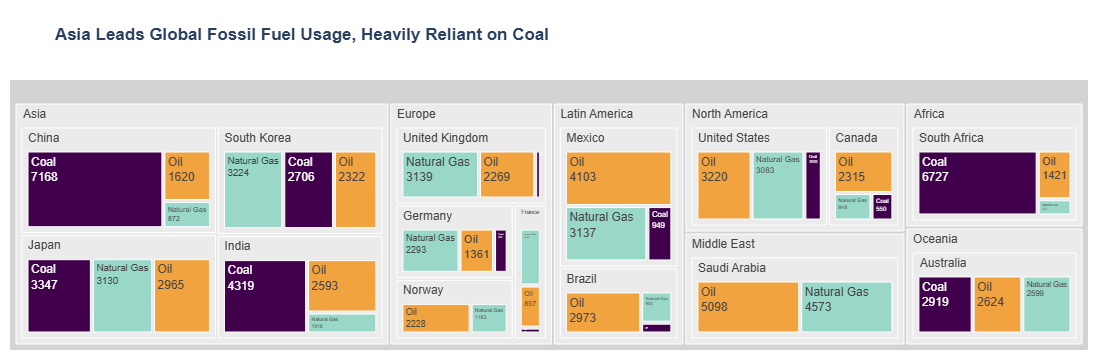

In [6]:
# 1. Filter fossil only
df_fossil = df.loc[df['Source_Type'] == 'Fossil'].copy()

# 2. Build the Treemap
fig1 = px.treemap(
    df_fossil,
    path=['Region', 'Country', 'Source'],
    values='TWh',
    color='Source',
    # New CVD-safe Palette (Color-blind friendly)
    color_discrete_map={
        'Coal': '#40004b',        # Dark Purple/Plum
        'Oil': '#f1a340',         # Bright Orange
        'Natural Gas': '#99d8c9', # Light Teal
        '(?)': '#EBEBEB'          # Very light grey for Region/Country
    },
    title='<b>Asia Leads Global Fossil Fuel Usage, Heavily Reliant on Coal</b>'
)

# 3. Update traces for labels and grey out parents
fig1.update_traces(
    textinfo="label+value",
    marker=dict(line=dict(width=1, color='white')),
    root_color="lightgrey"
)

fig1.update_layout(
    font=dict(family="Arial"),
    margin=dict(t=80, l=10, r=10, b=10)
)

fig1.show()

## Task 2 — Sunburst: tipping behaviour by day and meal time

**What to build:** A sunburst chart using the built-in `tips` dataset showing how **total bill amount** is distributed across day → time → smoker status.

**Requirements:**
- Load tips with `px.data.tips()`
- Aggregate **total bill** (sum of `total_bill`) per group — not count
- Hierarchy: `path=['day', 'time', 'smoker']`
- Colour encodes smoker status with a CVD-safe blue/orange palette
- Grey out parent nodes (day and time level)
- Use `percent parent` for text labels
- Insight title describing where the most spending happens

> 💡 `tips.groupby(['day', 'time', 'smoker'])['total_bill'].sum().reset_index()`


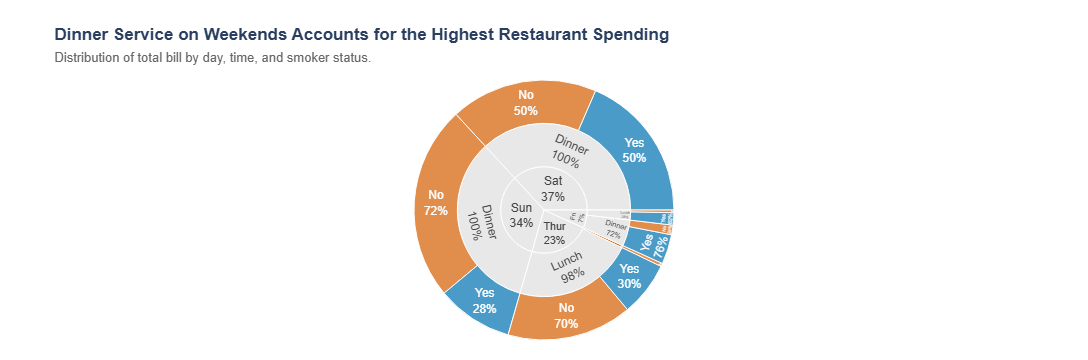

In [7]:
# 1. Load built-in dataset
tips = px.data.tips()

# 2. Aggregate total bill by group (Requirement 2)
tips_grouped = (
    tips.groupby(['day', 'time', 'smoker'])['total_bill']
    .sum()
    .reset_index()
)

# 3. Create Sunburst chart
fig2 = px.sunburst(
    tips_grouped,
    path=['day', 'time', 'smoker'], # Hierarchy
    values='total_bill',
    color='smoker',
    # CVD-safe blue/orange palette + Grey for parents (Rule 5)
    color_discrete_map={
        'Yes': '#0072B2',   # Strong Blue
        'No': '#D55E00',    # Vermillion/Orange
        '(?)': '#E8E8E8'    # Grey for parent nodes (day and time level)
    },
    title='<b>Dinner Service on Weekends Accounts for the Highest Restaurant Spending</b><br><span style="font-size:13px; color:#666666">Distribution of total bill by day, time, and smoker status.</span>'
)

# 4. Customise traces (Requirement 6 & 7)
fig2.update_traces(
    textinfo='label+percent parent', # Show percent of parent
    marker=dict(
        line=dict(color='white', width=1)
    ),
    hovertemplate='<b>%{label}</b><br>Total Bill: $%{value:,.2f}<extra></extra>'
)

# 5. Final layout cleanup
fig2.update_layout(
    margin=dict(t=80, l=20, r=20, b=20),
    font=dict(family="Arial")
)

fig2.show()

## Task 3 — Treemap vs bar: low-carbon energy by country

**What to build:** Build **both** a treemap and a horizontal bar chart showing total low-carbon TWh (Nuclear + Hydro) per country. Then answer the question in a markdown cell below.

**Requirements:**
- Filter to `Source_Type == 'Low-carbon'` and aggregate TWh by country
- Treemap: single-level `path=['All', 'Country']` with a dummy root node labelled `'Low-carbon'`
- Bar chart: sorted by TWh, horizontal orientation, CVD-safe colour
- Both charts show TWh values, not percentages
- Insight title on the bar chart naming the leading country


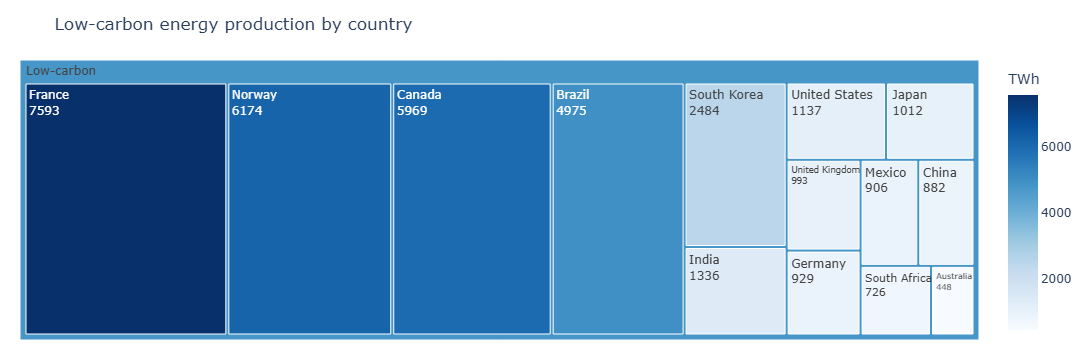

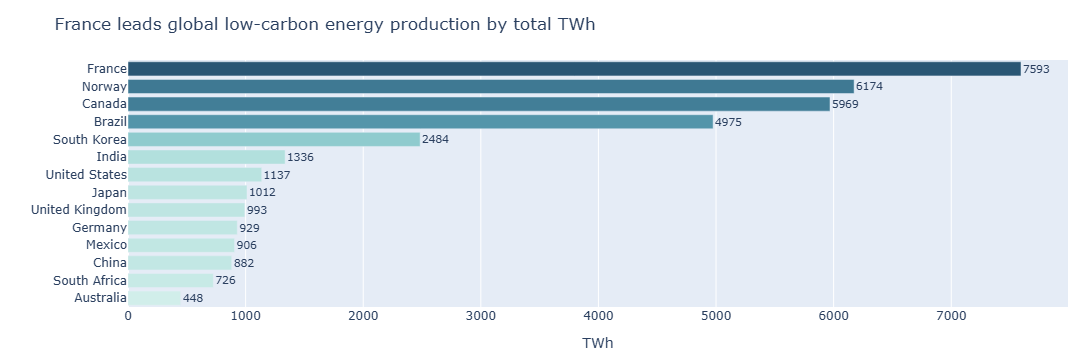

In [9]:
# Filter low-carbon sources
low_carbon_df = df.loc[df['Source_Type'] == 'Low-carbon']

# Aggregate TWh by country
low_carbon_country = (
    low_carbon_df.groupby('Country')['TWh']
    .sum()
    .reset_index()
)

# Add dummy root node for treemap
low_carbon_country['All'] = 'Low-carbon'

# TREEMAP

fig_tree = px.treemap(
    low_carbon_country,
    path=['All', 'Country'],
    values='TWh',
    color='TWh',
    color_continuous_scale='Blues',

    title='Low-carbon energy production by country'
)

fig_tree.update_traces(
    textinfo='label+value',
    root_color='#E8E8E8',

    marker=dict(
        line=dict(color='white', width=1)
    ),

    hovertemplate=
        '<b>%{label}</b><br>' +
        'TWh: %{value:,.0f}<extra></extra>'
)

fig_tree.update_layout(
    margin=dict(t=60, l=20, r=20, b=20)
)

fig_tree.show()

# HORIZONTAL BAR CHART

low_carbon_country = low_carbon_country.sort_values(
    by='TWh',
    ascending=True
)

fig_bar = px.bar(
    low_carbon_country,
    x='TWh',
    y='Country',
    orientation='h',
    text='TWh',

    color='TWh',
    color_continuous_scale='Teal',

    title='France leads global low-carbon energy production by total TWh'
)

fig_bar.update_traces(
    textposition='outside',

    hovertemplate=
        '<b>%{y}</b><br>' +
        'TWh: %{x:,.0f}<extra></extra>'
)

fig_bar.update_layout(
    margin=dict(t=60, l=20, r=20, b=20),
    coloraxis_showscale=False,
    yaxis_title='',
    xaxis_title='TWh'
)

fig_bar.show()